![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)

**Developers:** Zoltan Barta  
**Date:** 2026-03-04  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/4_td_learning/td_learning.ipynb)

# Practice 4: Temporal-Difference Learning

## Summary

In the Monte Carlo session, we estimated values from **complete episodes**. This was our first model-free approach, but it had one major limitation: the update could only happen after the episode finished.

In this session, we move to **Temporal-Difference (TD)** learning. TD methods update estimates immediately after each transition, which makes learning more online and often much more practical.

Content outline:
- why TD learning is the next step after Monte Carlo,
- the TD target and TD error,
- TD(0) prediction under a fixed policy,
- on-policy control with **SARSA**,
- off-policy control with **Q-learning**,
- empirical comparisons on **CliffWalking**.


## From Monte Carlo to Temporal-Difference Learning

Monte Carlo uses the full return:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

so the update must wait until the episode ends.

Temporal-Difference learning replaces this with a **bootstrapped** target. Instead of waiting for the complete return, it updates from the immediate reward and the next estimate:

$$
R_{t+1} + \gamma V(S_{t+1})
$$

This gives the TD(0) update:

$$
V(S_t) \leftarrow V(S_t) + \alpha \left[R_{t+1} + \gamma V(S_{t+1}) - V(S_t)\right]
$$

and the bracketed quantity is the **TD error**:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

So the conceptual shift is:
- **Monte Carlo:** learn from complete returns,
- **Temporal-Difference:** learn from one-step targets and bootstrap.


<div style="display:flex; justify-content:center; align-items:flex-start; gap:18px; margin:12px 0; flex-wrap:nowrap;">
  <div style="text-align:center; width:31%;">
    <div style="height:220px; display:flex; align-items:center; justify-content:center;">
      <img src="assets/DP.png" style="max-width:100%; max-height:220px; object-fit:contain;" />
    </div>
    <div style="margin-top:8px;"><b>Dynamic Programming (DP)</b></div>
    <div style="font-size:13px; color:#555;">
      Uses the full transition model of the environment to compute value estimates exactly.
    </div>
  </div>

  <div style="text-align:center; width:31%;">
    <div style="height:220px; display:flex; align-items:center; justify-content:center;">
      <img src="assets/MC.png" style="max-width:100%; max-height:220px; object-fit:contain;" />
    </div>
    <div style="margin-top:8px;"><b>Monte Carlo (MC)</b></div>
    <div style="font-size:13px; color:#555;">
      Estimates values from sampled complete episodes without requiring transition probabilities.
    </div>
  </div>

  <div style="text-align:center; width:31%;">
    <div style="height:220px; display:flex; align-items:center; justify-content:center;">
      <img src="assets/TD.png" style="max-width:100%; max-height:220px; object-fit:contain;" />
    </div>
    <div style="margin-top:8px;"><b>Temporal-Difference (TD)</b></div>
    <div style="font-size:13px; color:#555;">
      Learns directly from sampled transitions by bootstrapping from the current value estimate of the next state.
    </div>
  </div>
</div>

<div style="text-align:center; margin-top:12px; font-size:13px; max-width:980px; margin-left:auto; margin-right:auto;">
  <b>Figure.</b> Dynamic Programming, Monte Carlo, and Temporal-Difference learning all aim to estimate value functions, but they rely on different assumptions and update mechanisms. Dynamic Programming is model-based: it assumes that the transition dynamics of the environment are known and uses exact expected updates. Monte Carlo is model-free and learns from complete sampled episodes, updating only after the final return is observed. Temporal-Difference learning is also model-free, but it updates earlier, after each step, by combining the observed reward with the current estimate of the next state. In this sense, TD sits conceptually between DP and MC: like MC it learns from experience without a model, but like DP it bootstraps from existing value estimates. This usually makes TD more data-efficient than MC, while still being applicable in black-box environments.
  <br><br>
  <b>Source.</b> {cite}`lin2023reinforcementlearningbanditsspeech`
</div>


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import urllib.request

import numpy as np

try:
    import gymnasium as gym
except Exception:
    gym = None


def _load_session4_utils():
    candidates = [
        Path('utils.py'),
        Path('notebooks/sessions/4_td_learning/utils.py'),
        Path('/content/notebooks/sessions/4_td_learning/utils.py'),
    ]

    utils_path = next((p for p in candidates if p.exists()), None)

    if utils_path is None:
        utils_path = Path('notebooks/sessions/4_td_learning/utils.py')
        utils_path.parent.mkdir(parents=True, exist_ok=True)
        url = (
            'https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/'
            'notebooks/sessions/4_td_learning/utils.py'
        )
        urllib.request.urlretrieve(url, utils_path)

    spec = importlib.util.spec_from_file_location('session4_utils', utils_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


s4u = _load_session4_utils()
SEED = 42
GLOBAL_RNG = s4u.set_seed(SEED)


## Environment Setup

We use Gymnasium's `CliffWalking-v0` environment throughout the notebook.

The environment uses a flat state index, but conceptually it is a `4 x 12` grid. We will keep both views in mind:
- the code works with state indices,
- the visualizations interpret them as positions in the grid.


nS = 48
nA = 4
Note: CliffWalking transitions are deterministic (no true environment slip).
The map below is a teaching-only, hypothetical per-cell slip visualization.


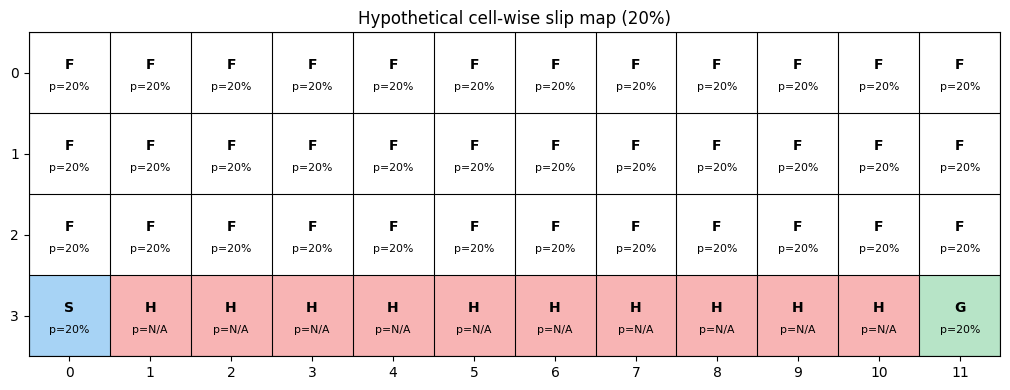

In [2]:
if gym is None:
    raise RuntimeError('Gymnasium is required for this notebook block. Please install gymnasium.')

env = gym.make('CliffWalking-v0')
nS = env.observation_space.n
nA = env.action_space.n
N_ROWS = 4
N_COLS = 12

print('nS =', nS)
print('nA =', nA)


print('Note: CliffWalking transitions are deterministic (no true environment slip).')
print('The map below is a teaching-only, hypothetical per-cell slip visualization.')
s4u.plot_cliffwalking_cell_slip(
    slip_prob=0.20,
    n_rows=N_ROWS,
    n_cols=N_COLS,
    title='Hypothetical cell-wise slip map (20%)',
)


**What this visualization shows**

The figure above gives a teaching-oriented overview of the `CliffWalking-v0` gridworld. It highlights the start state, the goal state, and the cliff region that causes the large negative penalty. Even though the environment dynamics themselves are deterministic, this map is useful because it makes the core control problem visually clear: the agent must balance taking a short route against avoiding the dangerous states near the cliff.


### CliffWalking trajectory visualization

We render one random trajectory with CliffWalking's native RGB environment render.

The helper saves both the full GIF and each frame separately under `assets/cell_outputs/`.


In [3]:
ASSET_ROOT = Path('notebooks/sessions/4_td_learning/assets/cell_outputs/cliffwalking')
if not ASSET_ROOT.parent.parent.exists():
    ASSET_ROOT = Path('assets/cell_outputs/cliffwalking')

random_traj = s4u.export_cliffwalking_random_trajectory_rgb(
    output_dir=ASSET_ROOT / 'random_walk',
    gif_name='cliffwalking_random_walk.gif',
    frame_prefix='rw',
    reset_seed=SEED,
    max_steps=25,
    fps=2.0,
)

print('Random walk return:', random_traj['total_return'], '| steps:', random_traj['steps_executed'])
print('Random walk GIF:', random_traj['gif_path'])


Random walk return: -421.0 | steps: 25
Random walk GIF: assets/cell_outputs/cliffwalking/random_walk/cliffwalking_random_walk.gif


<div style="display:flex; justify-content:center; margin:10px 0;">
  <div style="text-align:center;">
    <img src="assets/cell_outputs/cliffwalking/random_walk/cliffwalking_random_walk.gif" width="680" />
    <div>One random trajectory (native RGB render)</div>
  </div>
</div>


This GIF shows an untrained random rollout in the Cliff Walking environment. The trajectory is inefficient, often wanders without progress, and may repeatedly fall into the cliff, which makes the cost of unguided behavior immediately visible. Its role is to provide a baseline before learning: without value estimation and policy improvement, the agent has no reliable way to reach the goal safely or efficiently.


### Task 1

**Implement TD(0) prediction for a fixed policy (15 min)**

Following Sutton and Barto's Chapter 6 setup, we begin with **prediction**: the policy is fixed, and the goal is to estimate the state-value function

$$
v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s].
$$

In Session 3, Monte Carlo prediction estimated this by waiting until the **end of the episode**, then averaging complete returns. TD learning changes this idea in an important way: we update the value estimate **immediately after each transition**, without waiting for the full trajectory to finish.

Instead of the full return, TD(0) uses the **one-step bootstrapped target**

$$
R_{t+1} + \gamma V(S_{t+1}).
$$

This target says:

- take the **immediate reward** you just observed,
- then add the **discounted estimate of the next state**.

So TD does not wait to see the true long-term return. It uses its **current guess** about the future, which is why TD methods are called **bootstrapping** methods.

The difference between the target and the current estimate is the **TD error**:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t).
$$

The TD(0) update is then

$$
V(S_t) \leftarrow V(S_t) + \alpha \left[R_{t+1} + \gamma V(S_{t+1}) - V(S_t)\right].
$$

In this notebook, we provide a hand-crafted **safe policy** as the behavior policy. It moves up from the start, travels right on the safe row above the cliff, and goes down only near the goal.

Your task is to implement `td0_prediction(...)`.

Requirements:
- initialize a tabular value function `V` with zeros,
- generate episodes by following the provided fixed policy,
- after each step, compute the TD target and the TD error,
- update only the current state value `V[state]`,
- continue from the next state and repeat this online update at every step,
- stop an episode when the environment terminates or truncates,
- record the estimated value of the **start state** after each episode.


In [4]:
def state_to_rc(state: int, n_cols: int = N_COLS):
    """Convert a flat state index to (row, col)."""
    return divmod(int(state), int(n_cols))


def safe_cliff_policy(state: int) -> int:
    """Hand-crafted safe policy used for TD prediction.

    The policy moves up from the start row, traverses the row above the cliff,
    and then goes down near the goal.
    """
    row, col = state_to_rc(state)
    if row == N_ROWS - 1 and col == 0:
        return 0  # UP from the start
    if row == N_ROWS - 1:
        return 0  # if sent back to the start row, move UP again
    if row == N_ROWS - 2 and col < N_COLS - 1:
        return 1  # RIGHT along the safe row
    if row == N_ROWS - 2 and col == N_COLS - 1:
        return 2  # DOWN into the goal column
    return 1  # default fallback


def td0_prediction(env, policy_fn, n_episodes: int, alpha: float, gamma: float, max_steps: int = 200):
    """Run one-step TD(0) prediction for a fixed policy.

    This follows the Sutton-Barto TD(0) update:
        V(S_t) <- V(S_t) + alpha * [R_{t+1} + gamma * V(S_{t+1}) - V(S_t)]
    """
    V = np.zeros(env.observation_space.n, dtype=float)
    start_state_history = []

    ########################################################################
    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(GLOBAL_RNG.integers(0, 10_000_000)))
        state = int(state)

        for _ in range(max_steps):
            action = int(policy_fn(state))
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)

            td_target = float(reward)
            if not (terminated or truncated):
                td_target += gamma * V[next_state]

            td_error = td_target - V[state]
            V[state] += alpha * td_error
            state = next_state

            if terminated or truncated:
                break

        start_state_history.append(float(V[(N_ROWS - 1) * N_COLS]))
    ########################################################################

    return V, np.asarray(start_state_history, dtype=float)


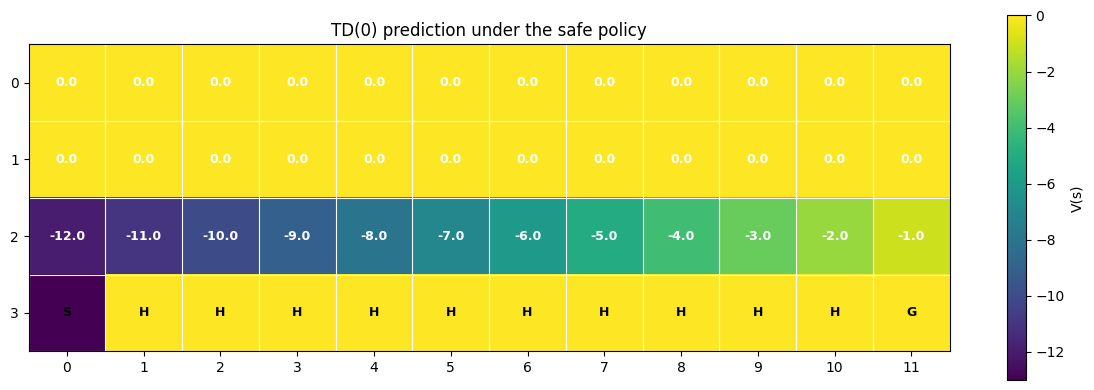

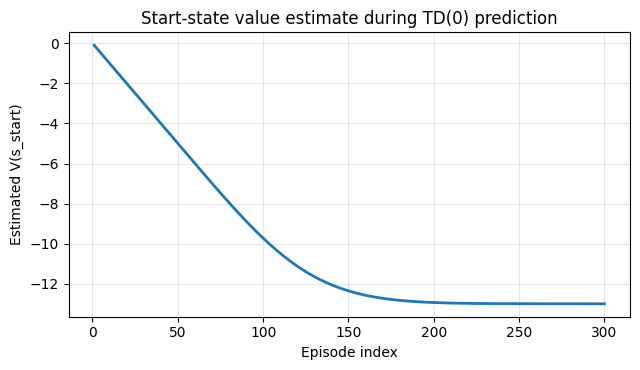

In [5]:
V_td, v0_hist = td0_prediction(env, safe_cliff_policy, n_episodes=300, alpha=0.1, gamma=1.0)

s4u.plot_cliffwalking_values(V_td, title='TD(0) prediction under the safe policy')
s4u.plot_return_curve(v0_hist, title='Start-state value estimate during TD(0) prediction', ylabel='Estimated V(s_start)')


The TD(0) value heatmap shows the values learned along the trajectory of the fixed safe policy. The states that are actually visited by the policy receive negative values, reflecting the step cost and the long path to the goal. By contrast, many upper-region states remain exactly `0`, which does not mean they are truly good states; it only means they were never visited, so TD(0) never updated them. The start-state estimate curve gradually stabilizes over training, although small fluctuations remain because TD(0) updates online after every step from one-step targets rather than waiting for full episodic returns.


## Experiment: TD step-size sensitivity

As in Session 3, we also want a simple sensitivity experiment.

For TD methods, the learning rate `alpha` has a strong effect:
- too small: learning is slow,
- too large: the estimate becomes noisy or unstable.

Below we compare the start-state value estimate under different `alpha` choices.


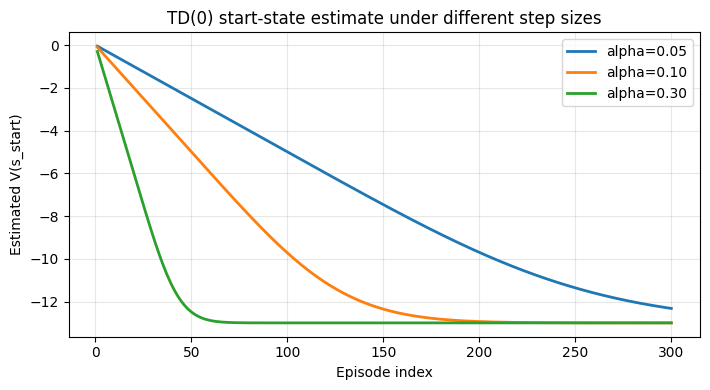

In [6]:
alpha_grid = [0.05, 0.10, 0.30]
episode_grid = np.arange(1, 301)
alpha_curves = {}

for alpha in alpha_grid:
    _, hist = td0_prediction(env, safe_cliff_policy, n_episodes=300, alpha=alpha, gamma=1.0)
    alpha_curves[alpha] = hist

s4u.plot_curves(
    episode_grid,
    [alpha_curves[alpha] for alpha in alpha_grid],
    [f'alpha={alpha:.2f}' for alpha in alpha_grid],
    title='TD(0) start-state estimate under different step sizes',
    xlabel='Episode index',
    ylabel='Estimated V(s_start)',
    marker=None,
)


This comparison shows the standard TD learning-rate tradeoff. With a smaller `alpha`, the start-state estimate changes more smoothly but adapts more slowly, while a larger `alpha` reacts faster to new experience at the cost of more visible oscillation. The figure therefore illustrates how the step size controls the balance between stability and adaptation speed in online TD updates.


## From Prediction to Control

The same transition applies here as in policy iteration and in Monte Carlo control:
- first estimate values,
- then improve the policy using those estimates.

For control, we work with **action values** `Q(s,a)` because we want to compare actions directly.

In TD learning, the important change is that both the evaluation and the improvement happen **online**, step by step.


### Task 2

**Implement SARSA (on-policy TD control) (15-20 min)**

Now we move from **prediction** to **control**. Instead of estimating only how good each state is under a fixed policy, we want to learn an **action-value function** that helps the agent improve its behavior over time.

SARSA is the classic **on-policy TD control** algorithm from Sutton and Barto. It learns the value of taking action `A_t` in state `S_t`, and then continuing to act according to the **same epsilon-greedy policy**.

Its update is based on the full transition tuple

$$
(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1}),
$$

which gives the algorithm its name: **State, Action, Reward, State, Action**.

The one-step SARSA update is

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)\right].
$$

The target here is

$$
R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}),
$$

so after observing the reward, SARSA looks at the **actual next action** selected by the current epsilon-greedy policy. This is what makes it **on-policy**: the same policy both

- generates the experience,
- and defines the target being learned.

In other words, SARSA does not ask: *“What is the best action I could take next?”* It asks: *“What action will I actually take next under my current exploratory policy?”*

This distinction matters a lot in CliffWalking. Because the agent is still exploring, the epsilon-greedy policy sometimes takes risky actions near the cliff. SARSA learns from those exploratory consequences directly, so it often prefers a **safer route** that is more robust under continued exploration.

The corresponding TD error is

$$
\delta_t = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t),
$$

and the update simply moves the current estimate a small step in that direction.

Your task is to implement `sarsa_control(...)`.

Requirements:
- initialize a tabular action-value function `Q` with zeros,
- start each episode from the environment reset,
- choose the first action using the provided `epsilon_greedy_action(...)`,
- after each step, observe `next_state`, `reward`, and termination flags,
- if the episode is not finished, choose `next_action` with the same epsilon-greedy policy,
- compute the SARSA target using the sampled `next_action`,
- update only `Q[state, action]`,
- move the `(state, action)` pair forward to `(next_state, next_action)`,
- stop when the environment terminates or truncates,
- record the total episodic return,
- also count how many times the agent falls into the cliff during the episode.




In [7]:
def epsilon_greedy_action(Q: np.ndarray, state: int, epsilon: float) -> int:
    """Sample an epsilon-greedy action from a tabular Q function."""
    if float(GLOBAL_RNG.random()) < float(epsilon):
        return int(GLOBAL_RNG.integers(0, Q.shape[1]))

    q_row = Q[int(state)]
    best_value = np.max(q_row)
    best_actions = np.flatnonzero(q_row == best_value)
    return int(GLOBAL_RNG.choice(best_actions))

In [8]:
def evaluate_greedy_return(env, greedy_actions: np.ndarray, n_eval_episodes: int = 100, max_steps: int = 200):
    """Evaluate a deterministic greedy policy by mean episodic return."""
    returns = []

    for _ in range(n_eval_episodes):
        state, _ = env.reset(seed=int(GLOBAL_RNG.integers(0, 10_000_000)))
        state = int(state)
        episode_return = 0.0

        for _ in range(max_steps):
            action = int(greedy_actions[state])
            state, reward, terminated, truncated, _ = env.step(action)
            state = int(state)
            episode_return += float(reward)
            if terminated or truncated:
                break

        returns.append(episode_return)

    returns = np.asarray(returns, dtype=float)
    return {
        'mean_return': float(returns.mean()),
        'std_return': float(returns.std()),
    }



In [9]:
def sarsa_control(env, n_episodes: int, alpha: float, gamma: float, epsilon: float, max_steps: int = 200):
    """Run one-step SARSA control."""
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = []
    cliff_falls = []

    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(GLOBAL_RNG.integers(0, 10_000_000)))
        state = int(state)
        action = epsilon_greedy_action(Q, state, epsilon)
        episode_return = 0.0
        episode_cliff_falls = 0
        ########################################################################

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)
            episode_return += float(reward)
            if float(reward) <= -100.0:
                episode_cliff_falls += 1

            td_target = float(reward)
            if not (terminated or truncated):
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                td_target += gamma * Q[next_state, next_action]
            else:
                next_action = None

            Q[state, action] += alpha * (td_target - Q[state, action])

            if terminated or truncated:
                break

            state = next_state
            action = int(next_action)

        ########################################################################
        episode_returns.append(episode_return)
        cliff_falls.append(float(episode_cliff_falls))

    greedy_policy = np.argmax(Q, axis=1)
    return {
        'Q': Q,
        'greedy_policy': greedy_policy,
        'episode_returns': np.asarray(episode_returns, dtype=float),
        'cliff_falls': np.asarray(cliff_falls, dtype=float),
    }


SARSA evaluation: {'mean_return': -17.0, 'std_return': 0.0}


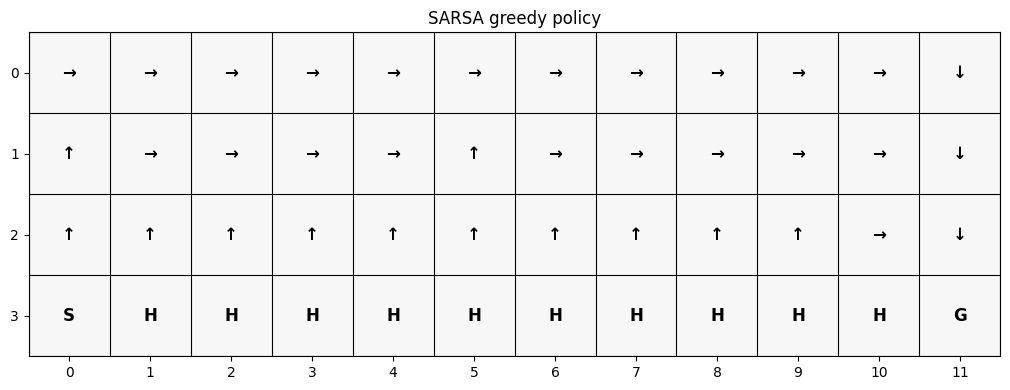

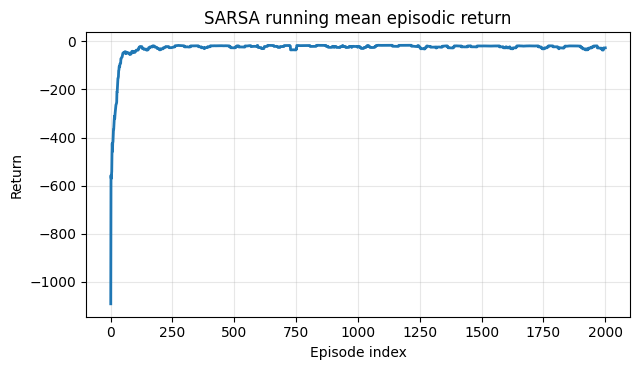

SARSA greedy rollout GIF: assets/cell_outputs/cliffwalking/sarsa_greedy/cliffwalking_sarsa_greedy.gif
SARSA greedy rollout return: -17.0


In [10]:
sarsa_res = sarsa_control(env, n_episodes=2000, alpha=0.2, gamma=1.0, epsilon=0.1)
sarsa_eval = evaluate_greedy_return(env, sarsa_res['greedy_policy'])

print('SARSA evaluation:', sarsa_eval)
s4u.plot_cliffwalking_policy(sarsa_res['greedy_policy'], title='SARSA greedy policy')
s4u.plot_return_curve(
    s4u.running_mean(sarsa_res['episode_returns'], window=25),
    title='SARSA running mean episodic return',
)

sarsa_gif = s4u.export_cliffwalking_greedy_trajectory(
    sarsa_res['greedy_policy'],
    output_dir=ASSET_ROOT / 'sarsa_greedy',
    gif_name='cliffwalking_sarsa_greedy.gif',
    frame_prefix='sarsa',
    reset_seed=SEED,
    max_steps=30,
    fps=2.0,
)
print('SARSA greedy rollout GIF:', sarsa_gif['gif_path'])
print('SARSA greedy rollout return:', sarsa_gif['total_return'])


<div style="display:flex; justify-content:center; margin:10px 0;">
  <div style="text-align:center;">
    <img src="assets/cell_outputs/cliffwalking/sarsa_greedy/cliffwalking_sarsa_greedy.gif" width="680" />
    <div>One greedy rollout under the learned SARSA policy</div>
  </div>
</div>


The learned greedy SARSA policy typically moves away from the cliff early and follows a safer route toward the goal. In the rollout GIF this usually appears as a longer but more conservative trajectory, which is exactly the behavior we expect from an on-policy method. Because SARSA learns from the epsilon-greedy behavior it actually follows during training, it tends to internalize the danger of states that are risky under continued exploration.


### Task 3

**Implement Q-learning (off-policy TD control) (15-20 min)**

The final core method in this session is **Q-learning**, the standard **off-policy TD control** algorithm from Sutton and Barto. Just like SARSA, it learns a tabular action-value function `Q(s, a)` and uses epsilon-greedy exploration during training. The crucial difference is in the **update target**.

Q-learning uses the update

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)\right].
$$

So after observing the next state and reward, it does **not** use the action that the behavior policy actually sampled next. Instead, it looks at the **best current estimate** available in the next state and updates toward that greedy value.

The one-step target is therefore

$$
R_{t+1} + \gamma \max_a Q(S_{t+1}, a),
$$

and the corresponding TD error is

$$
\delta_t = R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t).
$$

This makes Q-learning **off-policy**:

- the agent may behave according to an epsilon-greedy exploratory policy,
- but the update is learning about the **greedy target policy**, not the exploratory one.

That is the key conceptual difference from SARSA. SARSA learns, in effect, *“what happens if I keep behaving the way I currently act, including exploration?”* Q-learning instead learns, *“what would the return be if I acted greedily from the next state onward?”*

In CliffWalking, this difference is especially important. Because Q-learning updates toward the greedy next-state value, it often learns that the shortest path near the cliff is optimal. As a result, its final greedy policy is often **faster and more direct** than SARSA’s. However, during training, when exploration is still active, this can also make learning behavior more aggressive and less forgiving near the cliff.

Your task is to implement `q_learning_control(...)`.

Requirements:
- initialize a tabular action-value function `Q` with zeros,
- start each episode by resetting the environment,
- select actions with the provided `epsilon_greedy_action(...)`,
- after each step, observe `next_state`, `reward`, and the termination flags,
- compute the Q-learning target using the **maximum** action value in `next_state`,
- if the episode terminated or was truncated, use only the immediate reward as the target,
- update only `Q[state, action]`,
- continue from `next_state` until the episode ends,
- record the total episodic return,
- also count how many times the agent falls into the cliff during the episode.

In [11]:
def q_learning_control(env, n_episodes: int, alpha: float, gamma: float, epsilon: float, max_steps: int = 200):
    """Run one-step Q-learning control."""
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = []
    cliff_falls = []

    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(GLOBAL_RNG.integers(0, 10_000_000)))
        state = int(state)
        episode_return = 0.0
        episode_cliff_falls = 0

        ########################################################################
        for _ in range(max_steps):
            action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)
            episode_return += float(reward)
            if float(reward) <= -100.0:
                episode_cliff_falls += 1

            td_target = float(reward)
            if not (terminated or truncated):
                td_target += gamma * np.max(Q[next_state])

            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state

            if terminated or truncated:
                break

        ########################################################################
        episode_returns.append(episode_return)
        cliff_falls.append(float(episode_cliff_falls))

    greedy_policy = np.argmax(Q, axis=1)
    return {
        'Q': Q,
        'greedy_policy': greedy_policy,
        'episode_returns': np.asarray(episode_returns, dtype=float),
        'cliff_falls': np.asarray(cliff_falls, dtype=float),
    }


Q-learning evaluation: {'mean_return': -13.0, 'std_return': 0.0}


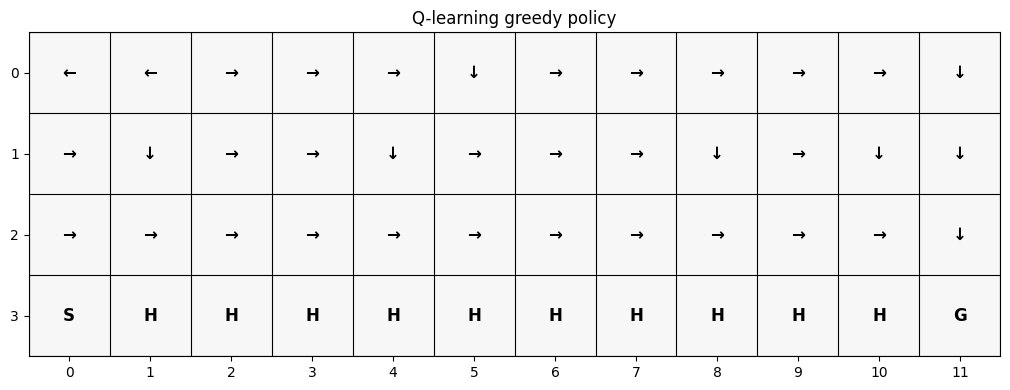

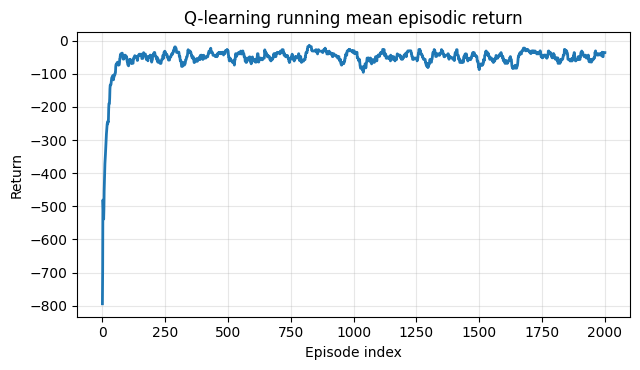

Q-learning greedy rollout GIF: assets/cell_outputs/cliffwalking/q_learning_greedy/cliffwalking_q_learning_greedy.gif
Q-learning greedy rollout return: -13.0


In [12]:
ql_res = q_learning_control(env, n_episodes=2000, alpha=0.2, gamma=1.0, epsilon=0.1)
ql_eval = evaluate_greedy_return(env, ql_res['greedy_policy'])

print('Q-learning evaluation:', ql_eval)
s4u.plot_cliffwalking_policy(ql_res['greedy_policy'], title='Q-learning greedy policy')
s4u.plot_return_curve(
    s4u.running_mean(ql_res['episode_returns'], window=25),
    title='Q-learning running mean episodic return',
)

ql_gif = s4u.export_cliffwalking_greedy_trajectory(
    ql_res['greedy_policy'],
    output_dir=ASSET_ROOT / 'q_learning_greedy',
    gif_name='cliffwalking_q_learning_greedy.gif',
    frame_prefix='ql',
    reset_seed=SEED,
    max_steps=30,
    fps=2.0,
)
print('Q-learning greedy rollout GIF:', ql_gif['gif_path'])
print('Q-learning greedy rollout return:', ql_gif['total_return'])


<div style="display:flex; justify-content:center; margin:10px 0;">
  <div style="text-align:center;">
    <img src="assets/cell_outputs/cliffwalking/q_learning_greedy/cliffwalking_q_learning_greedy.gif" width="680" />
    <div>One greedy rollout under the learned Q-learning policy</div>
  </div>
</div>


The greedy Q-learning policy usually prefers a shorter route that stays closer to the cliff. In the rollout GIF this appears as a more direct and efficient trajectory once exploration noise is removed. This matches the off-policy nature of Q-learning: its update targets the greedy next action, so it often learns the shorter optimal path even if that path is less forgiving during exploratory training.


## On-policy vs Off-policy

We already introduced the key distinction between **on-policy** and **off-policy** learning in the Monte Carlo setting. The same idea now becomes even more important in Temporal-Difference control, because SARSA and Q-learning differ exactly along this line.

At a high level, the question is:

- **Which policy generates the data?**
- **Which policy is being evaluated or improved?**

If these two roles are played by the **same policy**, the method is **on-policy**.  
If they are separated, the method is **off-policy**.

Formally, let

- $b$ denote the **behavior policy**, the policy that actually generates experience,
- $\pi$ denote the **target policy**, the policy whose value we want to evaluate or improve.

#### On-policy learning

In **on-policy** learning, we use the same policy for both roles:

$$
b = \pi
$$

This means that the agent learns directly from the behavior it actually follows. The sampled trajectories come from the same policy whose value function is being updated.

In Session 3, this was the case in **on-policy Monte Carlo control** with an $\epsilon$-greedy policy. The agent generated episodes with its current $\epsilon$-greedy policy, estimated returns from those same episodes, and then improved that same policy.

The same logic appears here in **SARSA**. Its update is

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Bigl[R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)\Bigr].
$$

The key point is that the next action $A_{t+1}$ is the action that the current policy actually chooses. So SARSA learns about the value of the **behavior policy itself**, including its exploratory decisions.

This matters in CliffWalking. If the behavior policy is $\epsilon$-greedy, then the agent sometimes takes random actions near the cliff. SARSA learns from those risky exploratory consequences directly, so it often prefers a more conservative route.

#### Off-policy learning

In **off-policy** learning, the behavior policy and the target policy are different:

$$
b \neq \pi
$$

The agent still collects data using one policy, but the update is aimed at another policy. In other words, the agent learns from trajectories that were not necessarily generated by the policy it ultimately wants to evaluate or optimize.

In Session 3, this appeared in **off-policy Monte Carlo prediction**, where episodes were generated by an exploratory behavior policy and then corrected using **importance sampling** to estimate the value of a different target policy.

In this session, the main off-policy example is **Q-learning**. Its update is

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Bigl[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)\Bigr].
$$

Here, the agent may still behave $\epsilon$-greedily while collecting experience, but the update target uses the **greedy next-state value**. So Q-learning is not learning the value of the exploratory behavior policy. Instead, it learns as if it were following the greedy policy from the next state onward.

That is why Q-learning is called **off-policy**: the sampled behavior can be exploratory, while the update target is greedy.

<div style="display:flex; justify-content:center; align-items:flex-start; gap:24px; margin:16px 0; flex-wrap:nowrap;">
  <div style="text-align:center; width:48%;">
    <div style="height:260px; display:flex; align-items:center; justify-content:center;">
      <img src="assets/Sarsa_backup.png" style="max-width:100%; max-height:260px; object-fit:contain;" />
    </div>
    <div style="margin-top:8px; font-size:14px;"><b>On-policy backup diagram</b></div>
  </div>

  <div style="text-align:center; width:48%;">
    <div style="height:260px; display:flex; align-items:center; justify-content:center;">
      <img src="assets/Qlearning_backup.png" style="max-width:100%; max-height:260px; object-fit:contain;" />
    </div>
    <div style="margin-top:8px; font-size:14px;"><b>Off-policy backup diagram</b></div>
  </div>
</div>

The two backup diagrams highlight the core difference between the two learning settings. In the **on-policy** case, the update follows the action that the current behavior policy actually selects, which is exactly the idea behind **SARSA**. In the **off-policy** case, the update is separated from the sampled behavior and instead backs up through the greedy choice, which is the key idea behind **Q-learning**. This small change in the backup target is what later produces the visible behavioral difference between the safer SARSA path and the more aggressive Q-learning path in CliffWalking.


## Experiment: SARSA vs Q-learning

This is the central comparison of the session.

The key theoretical point is that the two algorithms differ only in the target, but that small equation-level difference can lead to visibly different policies.

We compare:
- the final greedy policy,
- the running mean training return,
- and the final greedy evaluation return.


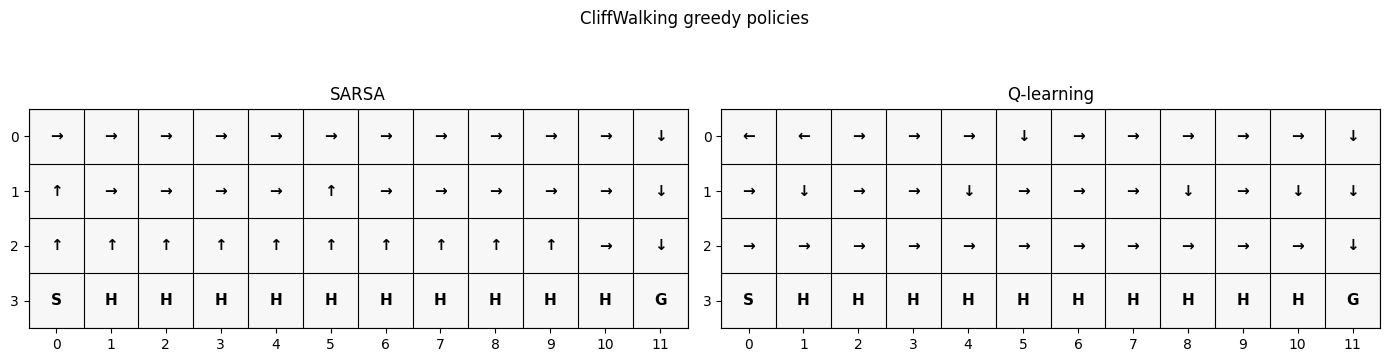

Final SARSA mean greedy return:      -17.0
Final Q-learning mean greedy return: -13.0
Comparison GIF: assets/cell_outputs/cliffwalking/policy_comparison/cliffwalking_sarsa_vs_q_learning.gif
SARSA rollout return in comparison GIF:      -17.0
Q-learning rollout return in comparison GIF: -13.0


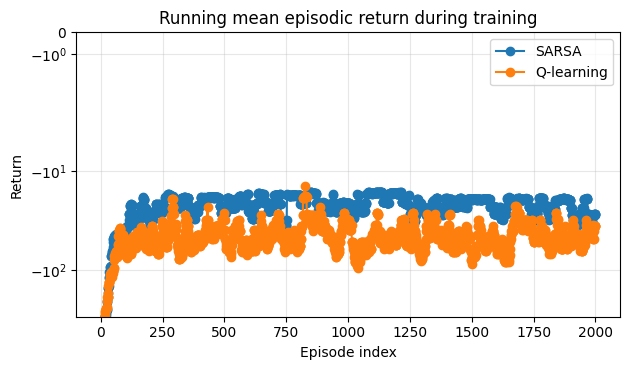

In [13]:
s4u.plot_policy_comparison(
    sarsa_res['greedy_policy'],
    ql_res['greedy_policy'],
    title_a='SARSA',
    title_b='Q-learning',
    suptitle='CliffWalking greedy policies',
)

ax = s4u.plot_curve_pair(
    np.arange(1, len(sarsa_res['episode_returns']) + 1),
    s4u.running_mean(sarsa_res['episode_returns'], window=25),
    s4u.running_mean(ql_res['episode_returns'], window=25),
    label1='SARSA',
    label2='Q-learning',
    title='Running mean episodic return during training',
    xlabel='Episode index',
    ylabel='Return',
    show=False,
)

ax.set_yscale('symlog', linthresh=5)
ax.set_ylim(-300, 0)


print('Final SARSA mean greedy return:     ', round(sarsa_eval['mean_return'], 3))
print('Final Q-learning mean greedy return:', round(ql_eval['mean_return'], 3))

comparison_gif = s4u.export_cliffwalking_policy_comparison_gif(
    sarsa_res['greedy_policy'],
    ql_res['greedy_policy'],
    output_dir=ASSET_ROOT / 'policy_comparison',
    label_left='SARSA: safer route',
    label_right='Q-learning: faster route',
    reset_seed=SEED,
    max_steps=30,
    gif_name='cliffwalking_sarsa_vs_q_learning.gif',
    frame_prefix='compare',
    fps=2.0,
)
print('Comparison GIF:', comparison_gif['gif_path'])
print('SARSA rollout return in comparison GIF:     ', comparison_gif['left_return'])
print('Q-learning rollout return in comparison GIF:', comparison_gif['right_return'])


<div style="display:flex; justify-content:center; margin:12px 0;">
  <div style="text-align:center;">
    <img src="assets/cell_outputs/cliffwalking/policy_comparison/cliffwalking_sarsa_vs_q_learning.gif" width="900" />
    <div>Side-by-side greedy rollout comparison: SARSA tends to stay safer, while Q-learning tends to take the faster route.</div>
  </div>
</div>

The expected interpretation is:
- **SARSA** learns the value of the exploratory policy itself, so it tends to internalize the danger of acting near the cliff while exploration is still active.
- **Q-learning** updates toward the greedy target and therefore tends to learn a more aggressive path.

So the main lesson is that the difference between **on-policy** and **off-policy** learning affects not just the equations, but also the final behavior.


This comparison makes the behavioral difference between the two methods easy to see. SARSA typically chooses the safer route farther from the cliff, while Q-learning tends to prefer the shorter path near the edge. The training-return curves show that this is not only a difference in the final greedy policy but also in how the algorithms behave throughout learning, and the side-by-side GIF turns that equation-level distinction into a concrete visual contrast.


## Experiment: risk during training

In CliffWalking, the most meaningful difference is often not just the final greedy policy, but how risky the learning process is while exploration is active.

A simple proxy for this is the number of times the agent falls into the cliff during training. Sutton and Barto's discussion suggests that SARSA should usually internalize this risk more strongly, while Q-learning often remains more aggressive during learning.


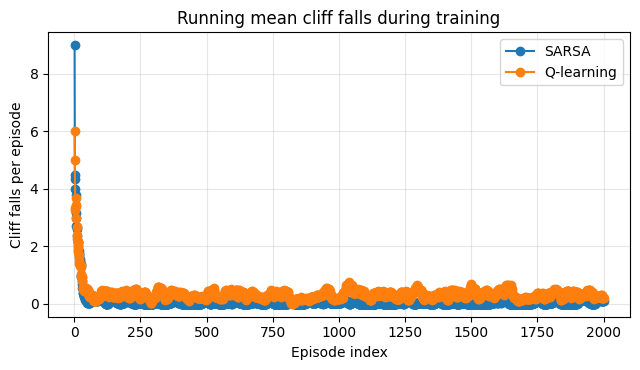

Total SARSA cliff falls during training:      110
Total Q-learning cliff falls during training: 654
Average SARSA cliff falls / episode:          0.055
Average Q-learning cliff falls / episode:     0.327


In [14]:
episode_axis = np.arange(1, len(sarsa_res['cliff_falls']) + 1)

s4u.plot_curve_pair(
    episode_axis,
    s4u.running_mean(sarsa_res['cliff_falls'], window=25),
    s4u.running_mean(ql_res['cliff_falls'], window=25),
    label1='SARSA',
    label2='Q-learning',
    title='Running mean cliff falls during training',
    xlabel='Episode index',
    ylabel='Cliff falls per episode',
)

print('Total SARSA cliff falls during training:     ', int(np.sum(sarsa_res['cliff_falls'])))
print('Total Q-learning cliff falls during training:', int(np.sum(ql_res['cliff_falls'])))
print('Average SARSA cliff falls / episode:         ', round(float(np.mean(sarsa_res['cliff_falls'])), 3))
print('Average Q-learning cliff falls / episode:    ', round(float(np.mean(ql_res['cliff_falls'])), 3))


This figure focuses on how risky the learning process is while exploration is still active by tracking how often each method falls into the cliff during training. SARSA usually accumulates fewer cliff falls because it evaluates the exploratory policy it actually follows, whereas Q-learning often remains more willing to approach the cliff while learning. The plot therefore highlights that the most important difference between the methods may appear during training, not only in the final greedy policy.


## Experiment: epsilon sensitivity

As in Session 3, the amount of exploration matters.

Here, `epsilon` changes how often the agent takes exploratory actions during training. In CliffWalking this directly changes how often the agent risks stepping near the cliff.

Below we compare the final greedy performance of SARSA and Q-learning for multiple epsilon values.


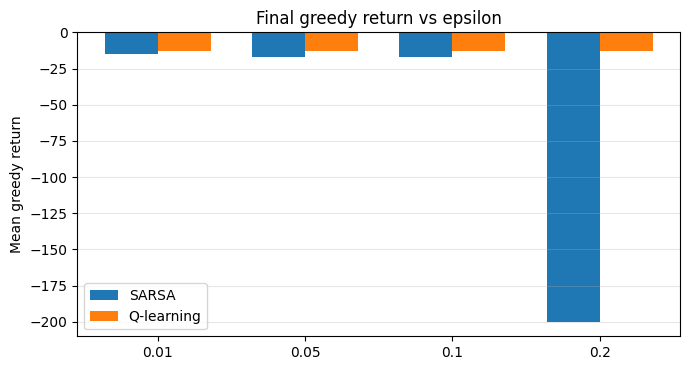

In [15]:
eps_grid = [0.01, 0.05, 0.10, 0.20]
sarsa_scores = []
ql_scores = []

for eps in eps_grid:
    sarsa_tmp = sarsa_control(env, n_episodes=300, alpha=0.5, gamma=1.0, epsilon=eps)
    ql_tmp = q_learning_control(env, n_episodes=300, alpha=0.5, gamma=1.0, epsilon=eps)

    sarsa_scores.append(evaluate_greedy_return(env, sarsa_tmp['greedy_policy'])['mean_return'])
    ql_scores.append(evaluate_greedy_return(env, ql_tmp['greedy_policy'])['mean_return'])

s4u.plot_bar_pair(
    [str(e) for e in eps_grid],
    sarsa_scores,
    ql_scores,
    name_a='SARSA',
    name_b='Q-learning',
    title='Final greedy return vs epsilon',
    ylabel='Mean greedy return',
)


This plot shows how changing `epsilon` affects the final learned behavior through the amount of exploration used during training. Larger `epsilon` values expose the agent more often to risky states near the cliff, and SARSA usually responds more strongly to that because it learns the value of the exploratory policy itself. Q-learning often remains comparatively optimistic about the greedy path, so the figure helps clarify how on-policy and off-policy learning react differently to increasing exploration.


## Experiment: training budget sensitivity

Finally, we also want the same kind of practical question as in Session 3:

- how much does performance improve as we increase the number of training episodes?

This is especially useful here because TD learning is online, so the learning curve is one of the most important practical views of the algorithm.


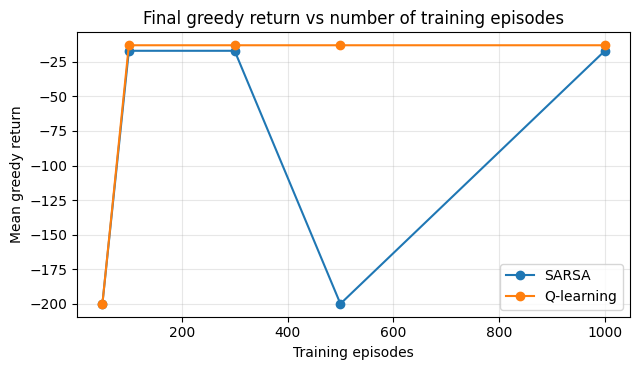

<Axes: title={'center': 'Final greedy return vs number of training episodes'}, xlabel='Training episodes', ylabel='Mean greedy return'>

In [16]:
episode_grid = [50, 100, 300, 500, 1000]
sarsa_budget = []
ql_budget = []

for n_eps in episode_grid:
    sarsa_tmp = sarsa_control(env, n_episodes=n_eps, alpha=0.5, gamma=1.0, epsilon=0.1)
    ql_tmp = q_learning_control(env, n_episodes=n_eps, alpha=0.5, gamma=1.0, epsilon=0.1)

    sarsa_budget.append(evaluate_greedy_return(env, sarsa_tmp['greedy_policy'])['mean_return'])
    ql_budget.append(evaluate_greedy_return(env, ql_tmp['greedy_policy'])['mean_return'])

s4u.plot_curve_pair(
    episode_grid,
    sarsa_budget,
    ql_budget,
    label1='SARSA',
    label2='Q-learning',
    title='Final greedy return vs number of training episodes',
    xlabel='Training episodes',
    ylabel='Mean greedy return',
)


This figure shows how the two methods improve as the number of training episodes increases. With small training budgets both algorithms can still be noisy or undertrained, but as more experience is collected their characteristic behaviors become clearer. The plot is therefore a practical view of sample efficiency: it shows not just which method can perform well, but how quickly that behavior emerges with additional training.
